## Visualize stupid thing

In [43]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [24]:
rt_df = pd.read_csv('../datasets/Cat_only_rt.csv')

In [25]:
from ydata_profiling import ProfileReport
ProfileReport(rt_df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 84.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Correlation Matrix

In [ ]:
corr = rt_df[['year', 'occurrenceCount']].corr()
corr.style.background_gradient(cmap='coolwarm')

,year,occurrenceCount
year,1.000000,0.159217
occurrenceCount,0.159217,1.000000


In [27]:
rt_df.head()

,year,stateTerritory,ibraRegion,forest2018Status,forest2013Status,capadStatus,speciesName,occurrenceCount
0,1960,New South Wales,South East Corner,forest,forest,not protected,Felis catus,3
1,1960,New South Wales,South Eastern Highlands,forest,non-forest,not protected,Felis catus,1
2,1960,New South Wales,South Eastern Queensland,forest,forest,not protected,Felis catus,1
3,1960,Australian Capital Territory,South Eastern Highlands,non-forest,non-forest,not protected,Felis catus,1
4,1961,Northern Territory,Daly Basin,forest,non-forest,not protected,Felis catus,1


In [28]:
print(f"Unique\nForest 2013: {rt_df['forest2013Status'].unique()}\nForest 2018: {rt_df['forest2018Status'].unique()}\ncapad Status: {rt_df['capadStatus'].unique()}\nState Territory: {rt_df['stateTerritory'].unique()}")

Unique
Forest 2013: ['forest' 'non-forest']
Forest 2018: ['forest' 'non-forest']
capad Status: ['not protected' 'PA' 'IPA']
State Territory: ['New South Wales' 'Australian Capital Territory' 'Northern Territory'
 'Victoria' 'Queensland' 'Western Australia' 'South Australia' 'Tasmania'
 'Unknown1']


In [29]:
# Quick mapping
rt_df['forest2013BNRY'] = rt_df['forest2013Status'].map({'non-forest': 0, 'forest': 1})
rt_df['forest2018BNRY'] = rt_df['forest2018Status'].map({'non-forest': 0, 'forest': 1})
rt_df['is_protected'] = rt_df['capadStatus'].map({'not protected': 0, 'PA': 1, 'IPA': 2})

In [30]:
rt_df[['forest2013BNRY', 'forest2018BNRY']]

,forest2013BNRY,forest2018BNRY
0,1,1
1,0,1
2,1,1
3,0,0
4,0,1
...,...,...
4944,0,0
4945,0,0
4946,1,1
4947,0,0


In [31]:
from sklearn.preprocessing import OneHotEncoder

# Reshape is needed because the encoder expects a 2D array
data = np.array(['New South Wales', 'South Australia', 'Queensland', 
                 'Northern Territory', 'Tasmania', 'ACT', 'Victoria', 
                 'Western Australia', np.nan, 'Unknown1']).reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(data)

In [32]:
rt_df['ibraRegion'].unique()

array(['South East Corner', 'South Eastern Highlands',
       'South Eastern Queensland', 'Daly Basin',
       'Murray Darling Depression', 'Riverina', 'Mulga Lands', 'Pilbara',
       'Sydney Basin', 'Eyre Yorke Block', 'Central Ranges',
       'Flinders Lofty Block', 'Brigalow Belt South',
       'Southern Volcanic Plain', 'MacDonnell Ranges', 'Nullarbor',
       'Victorian Midlands', 'Burt Plain', 'Davenport Murchison Ranges',
       'Finke', 'Simpson Strzelecki Dunefields',
       'NSW South Western Slopes', 'Kanmantoo',
       'Naracoorte Coastal Plain', 'Mitchell Grass Downs',
       'Darling Riverine Plains', 'Gawler', 'South East Coastal Plain',
       'NSW North Coast', 'Great Sandy Desert', 'Sturt Plateau', 'Tanami',
       'Central Mackay Coast', 'Pine Creek', 'Victoria Bonaparte',
       'Cape York Peninsula', 'Darwin Coastal', 'Australian Alps',
       'Brigalow Belt North', 'Arnhem Plateau',
       'Tasmanian Northern Slopes', 'Channel Country', 'Nandewar',
       'Furnea

## Bar Graphs


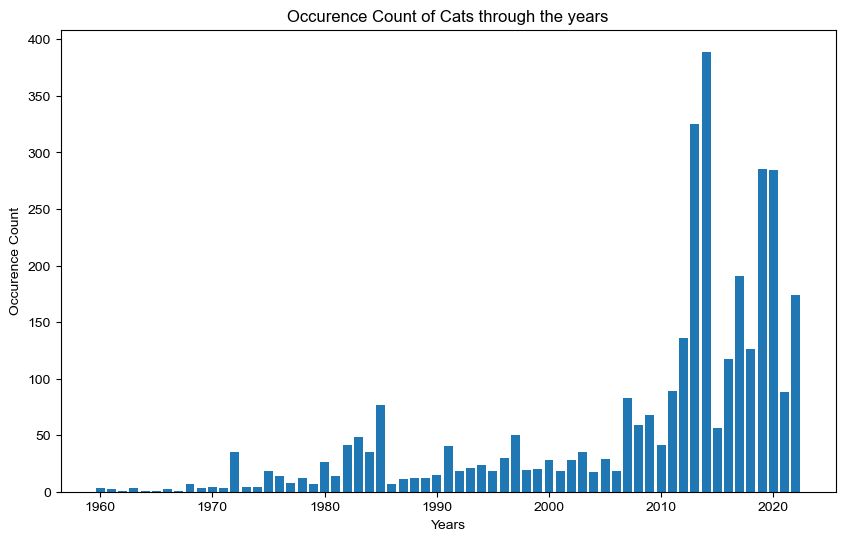

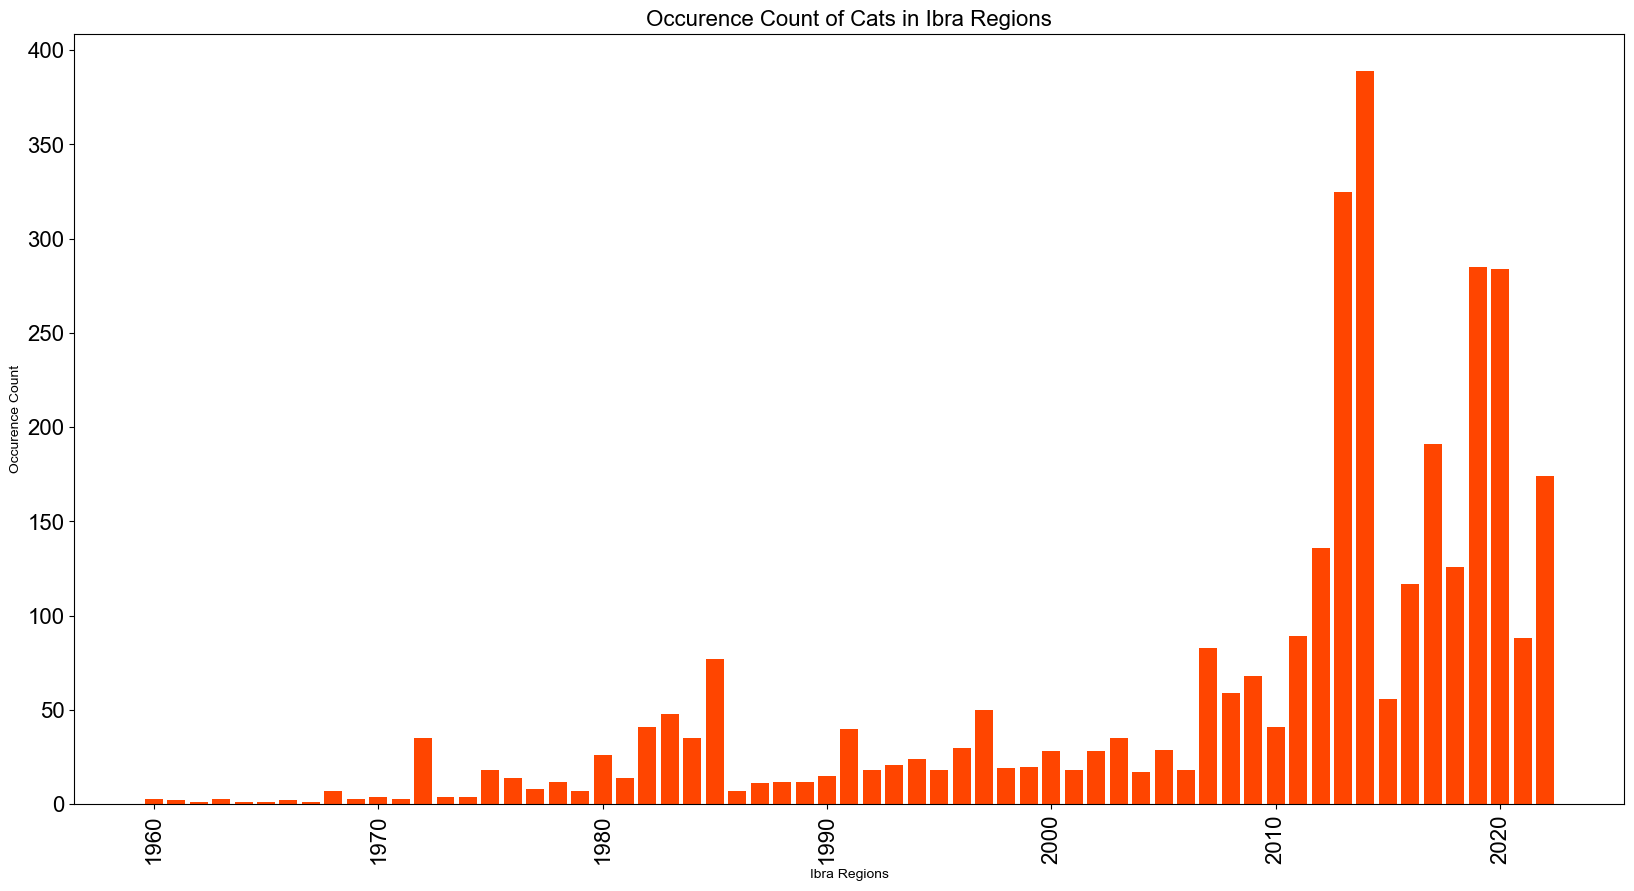

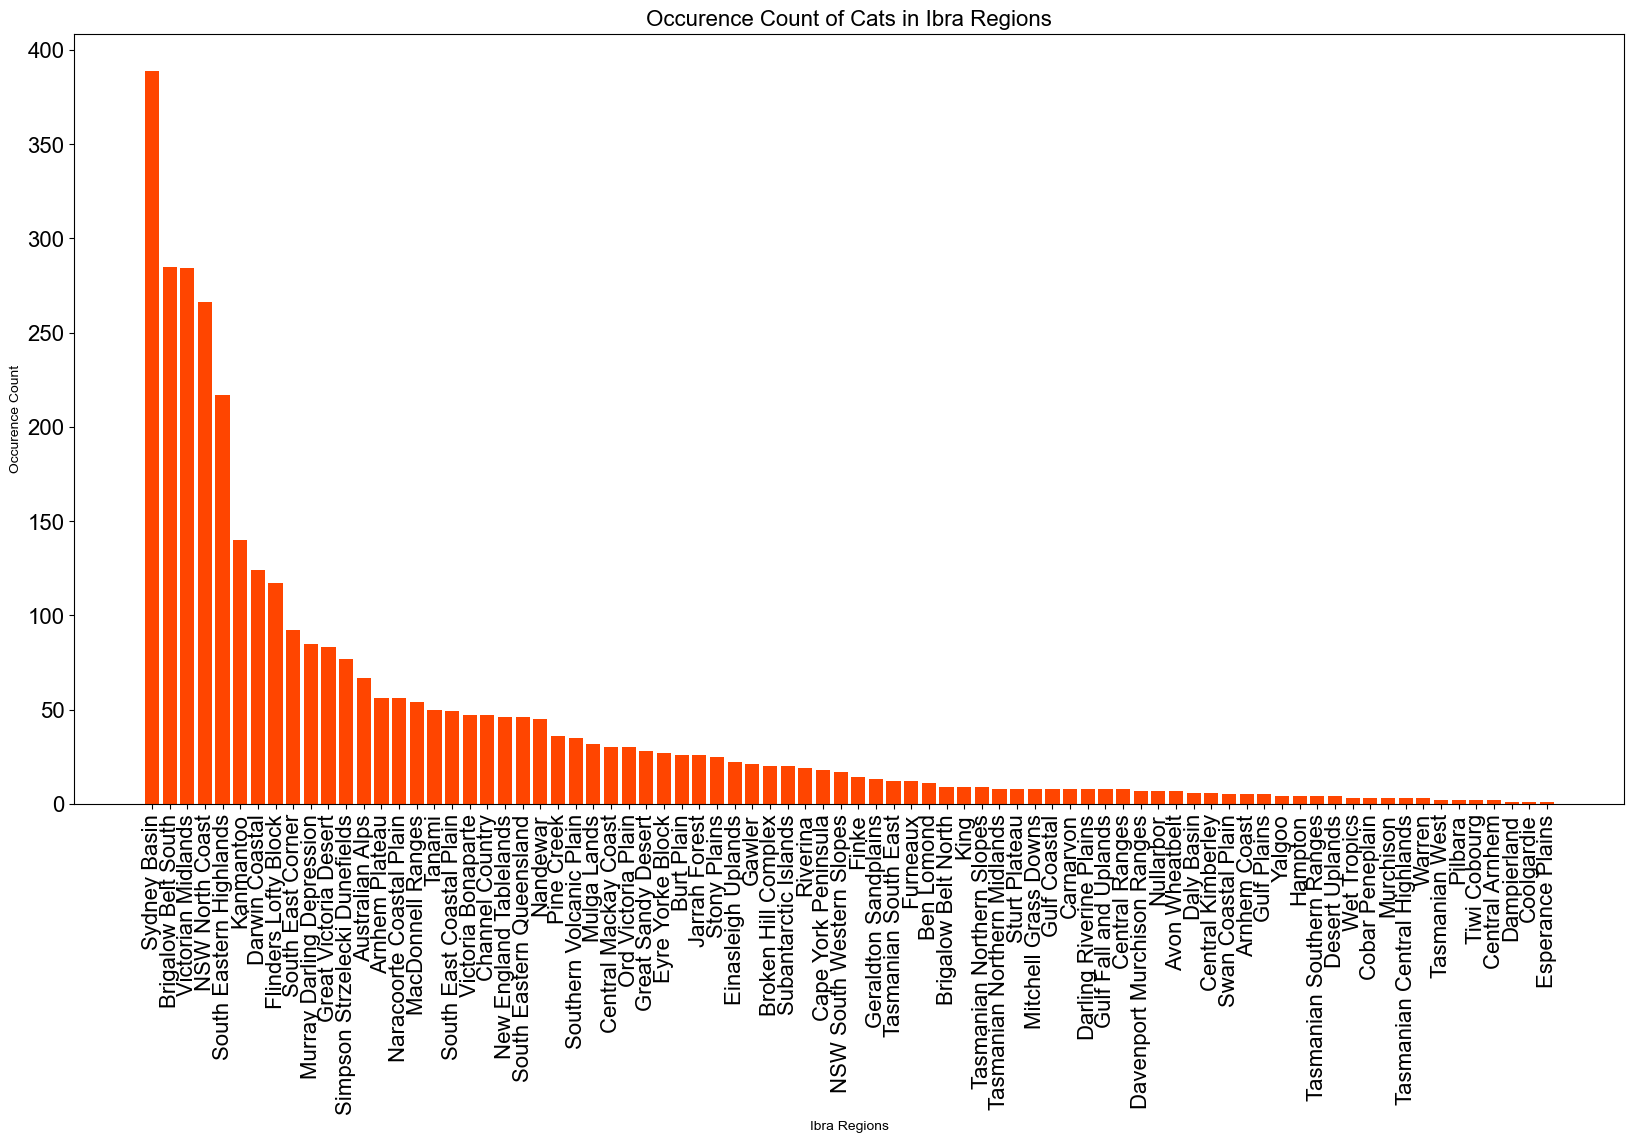

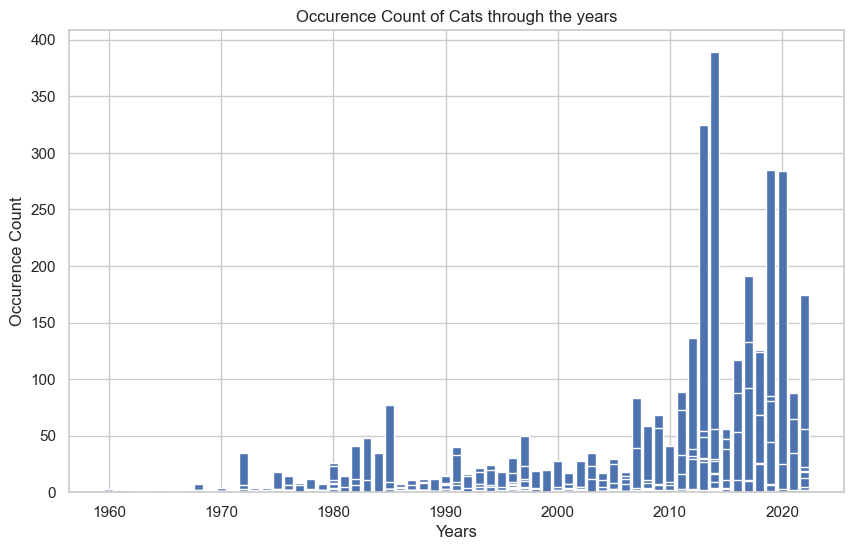

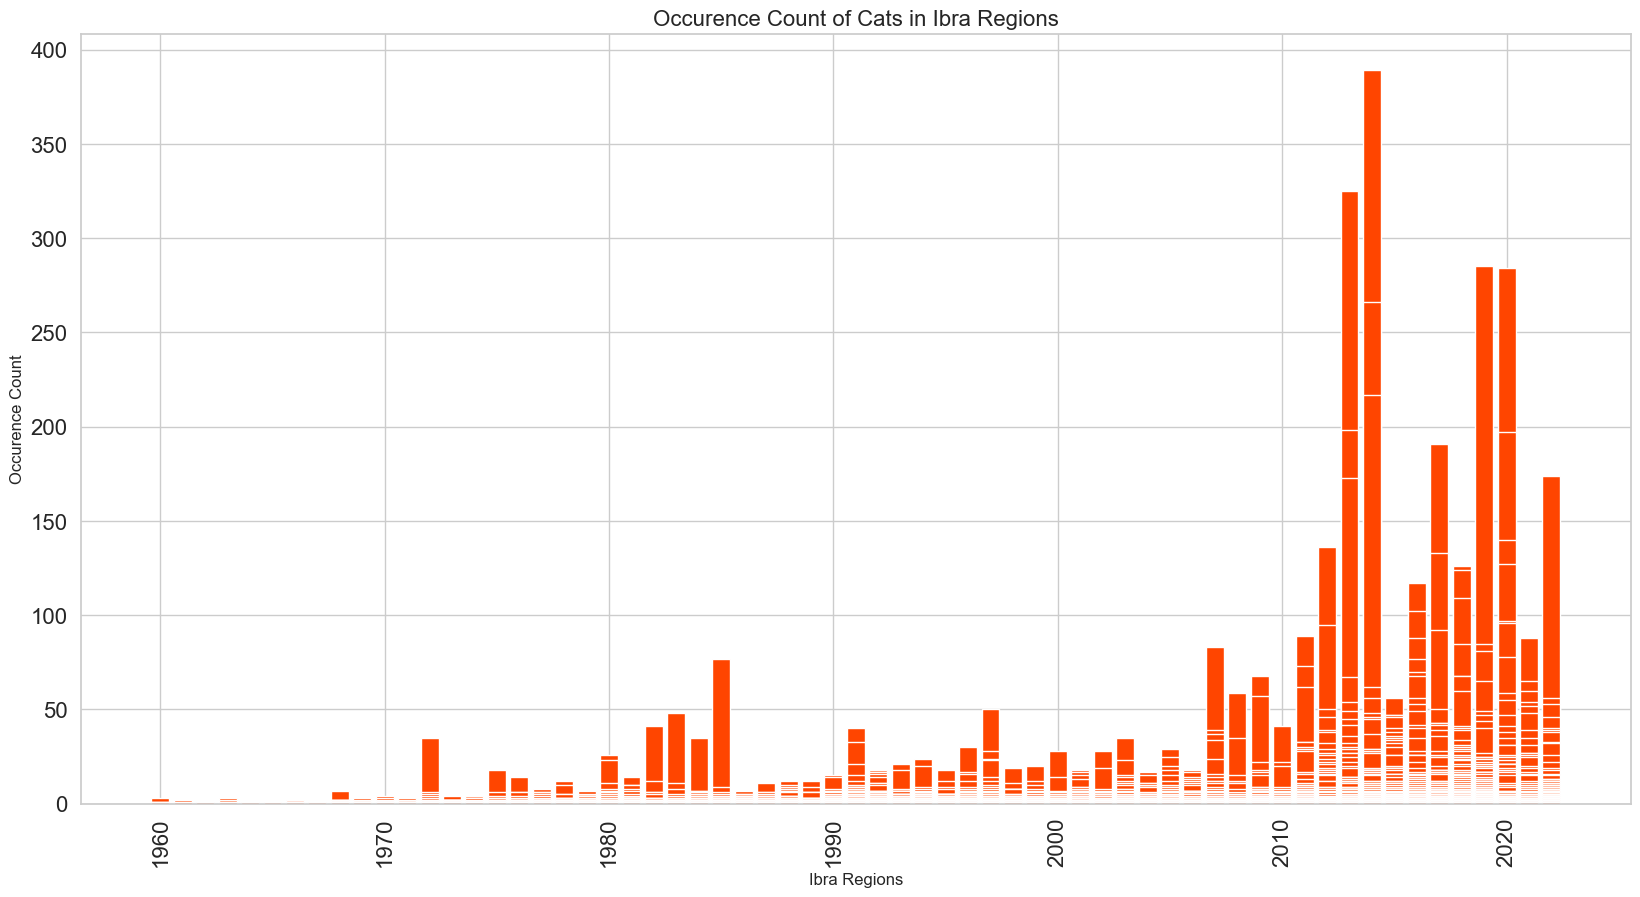

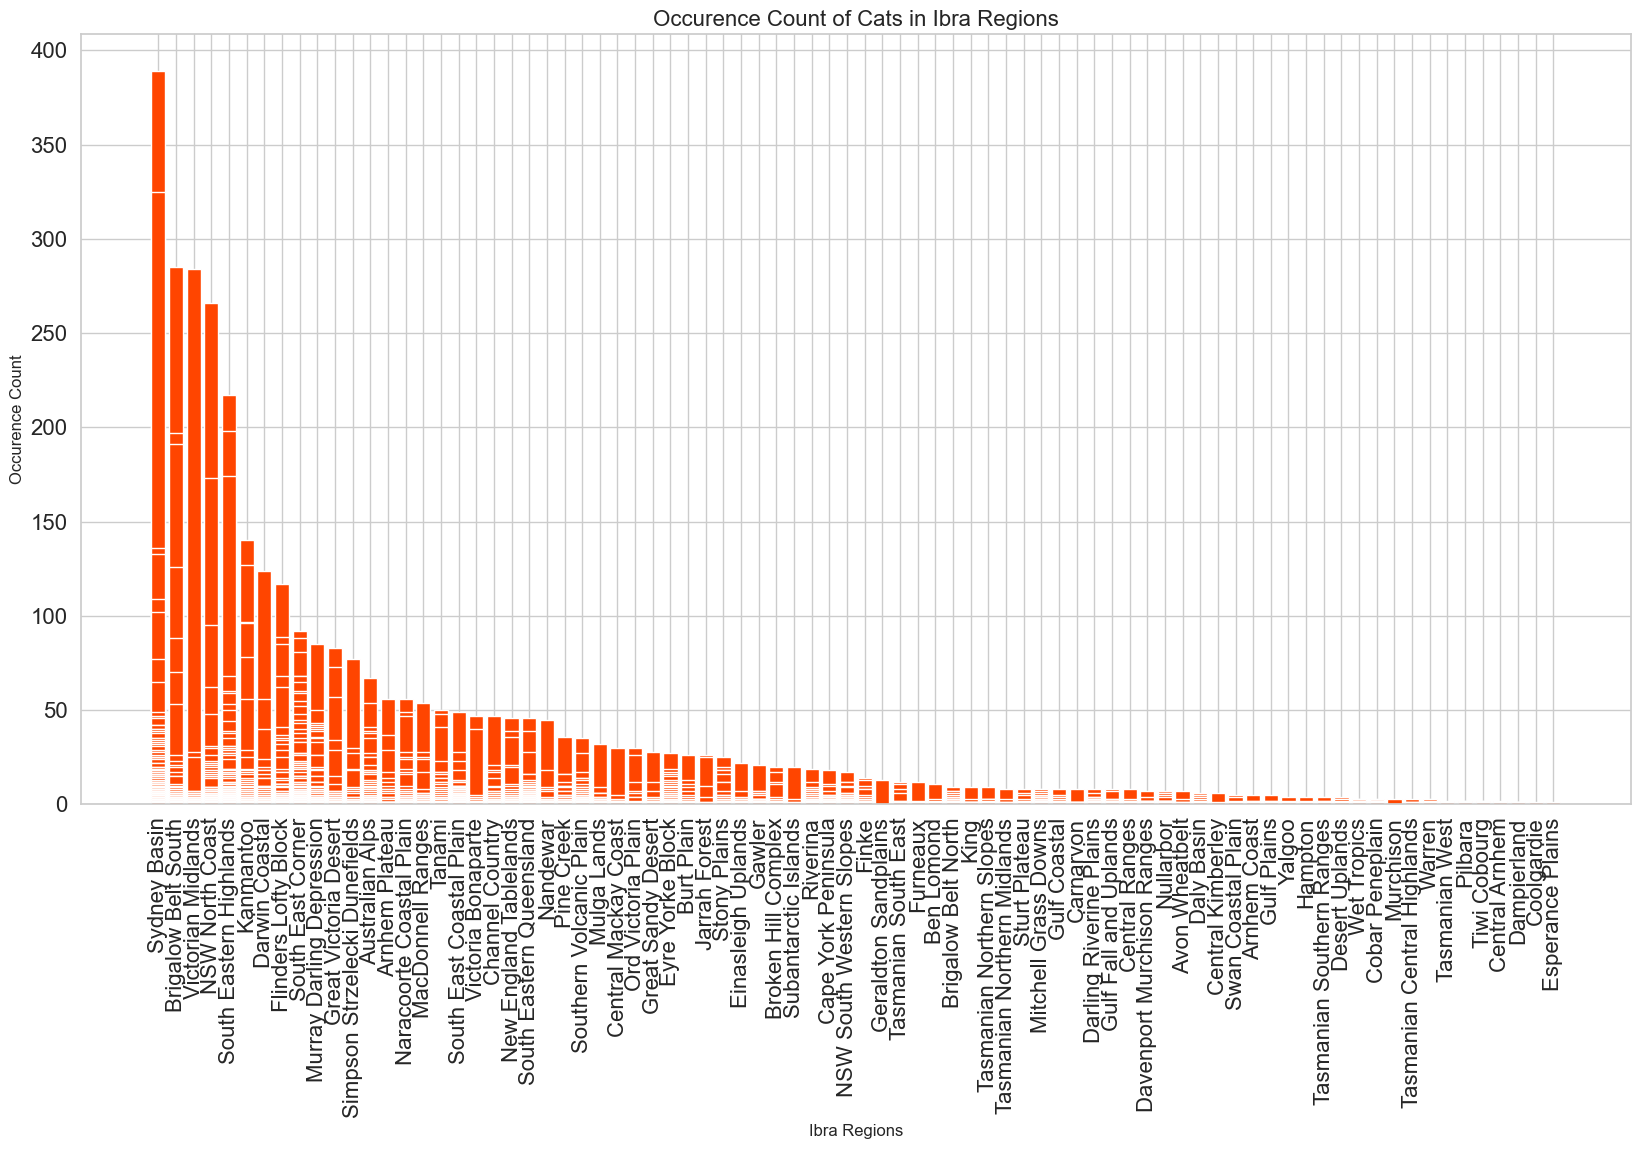

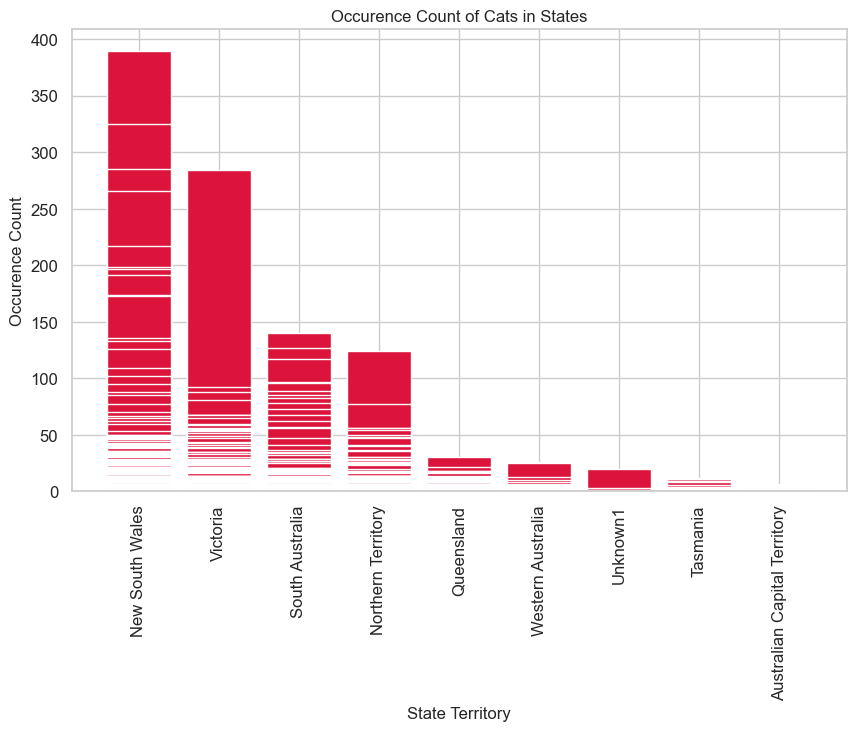

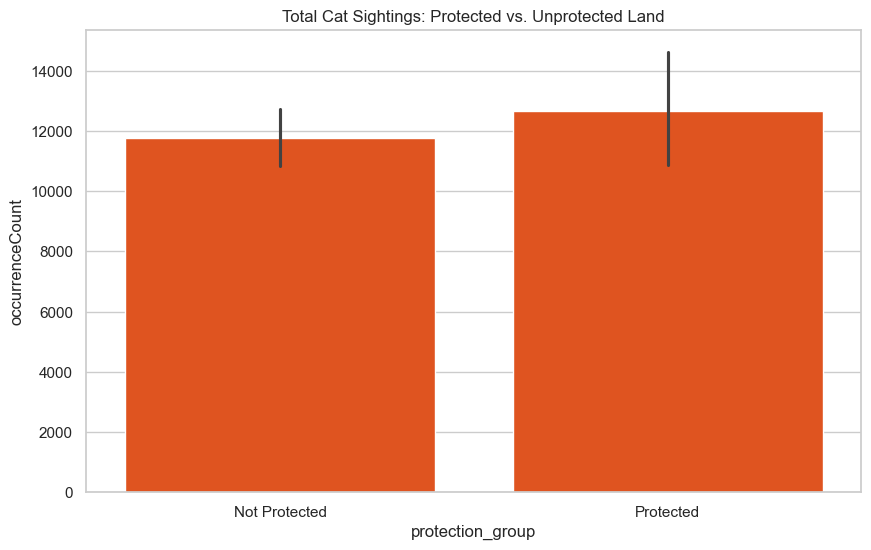

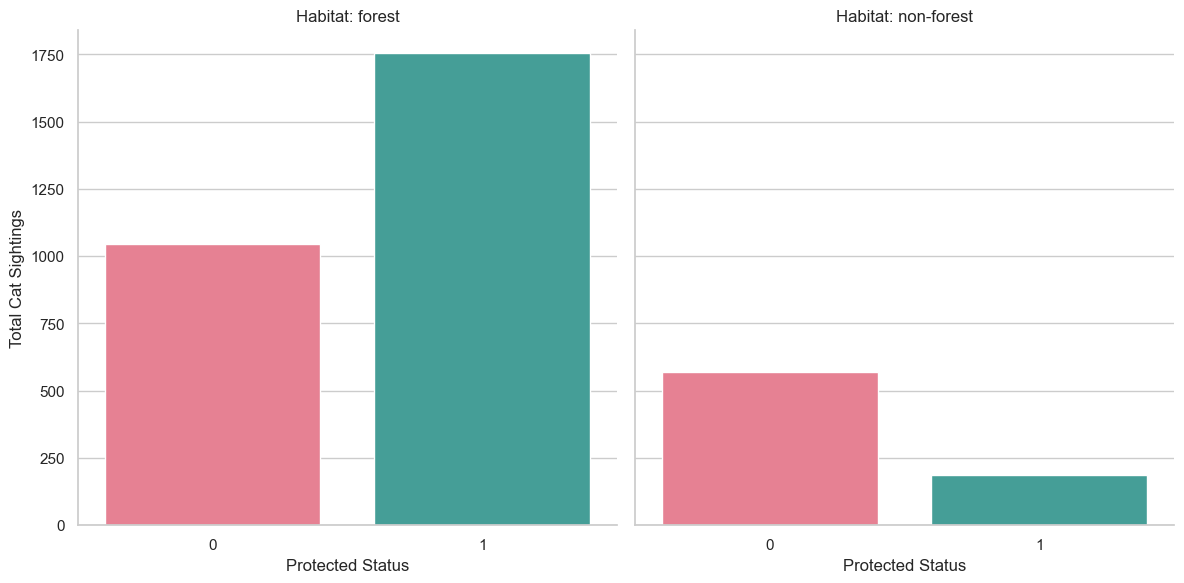

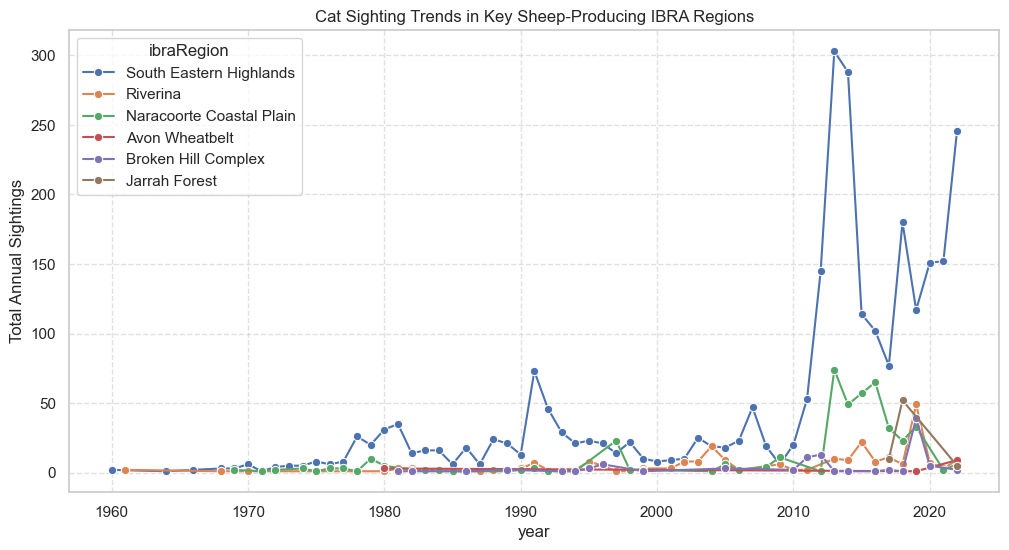

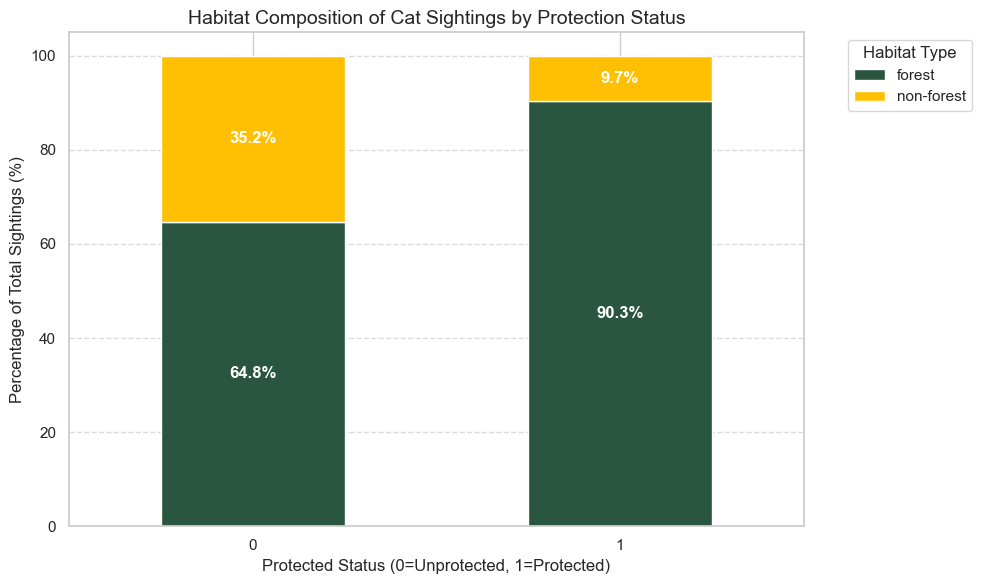

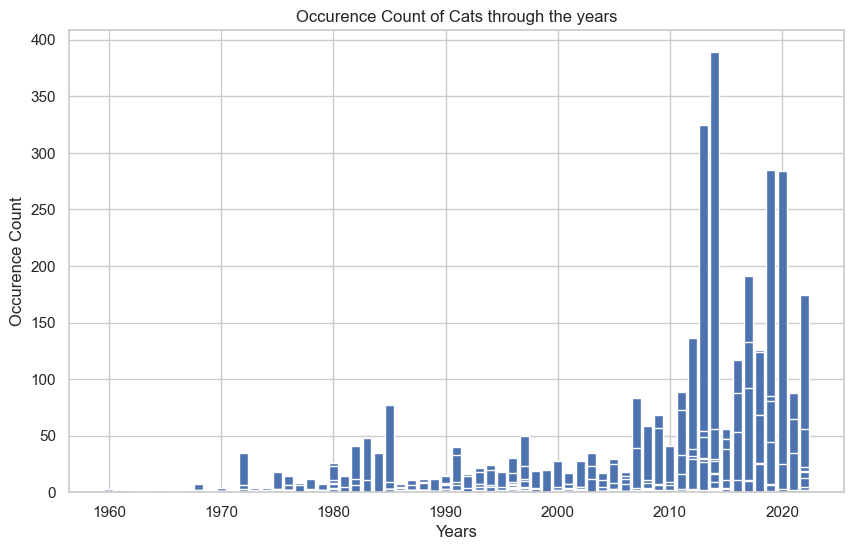

In [44]:
plt.figure(figsize=(10, 6))
plt.bar(rt_df['year'], rt_df['occurrenceCount'])
plt.xlabel('Years')
plt.ylabel('Occurence Count')
plt.title('Occurence Count of Cats through the years')
plt.show()

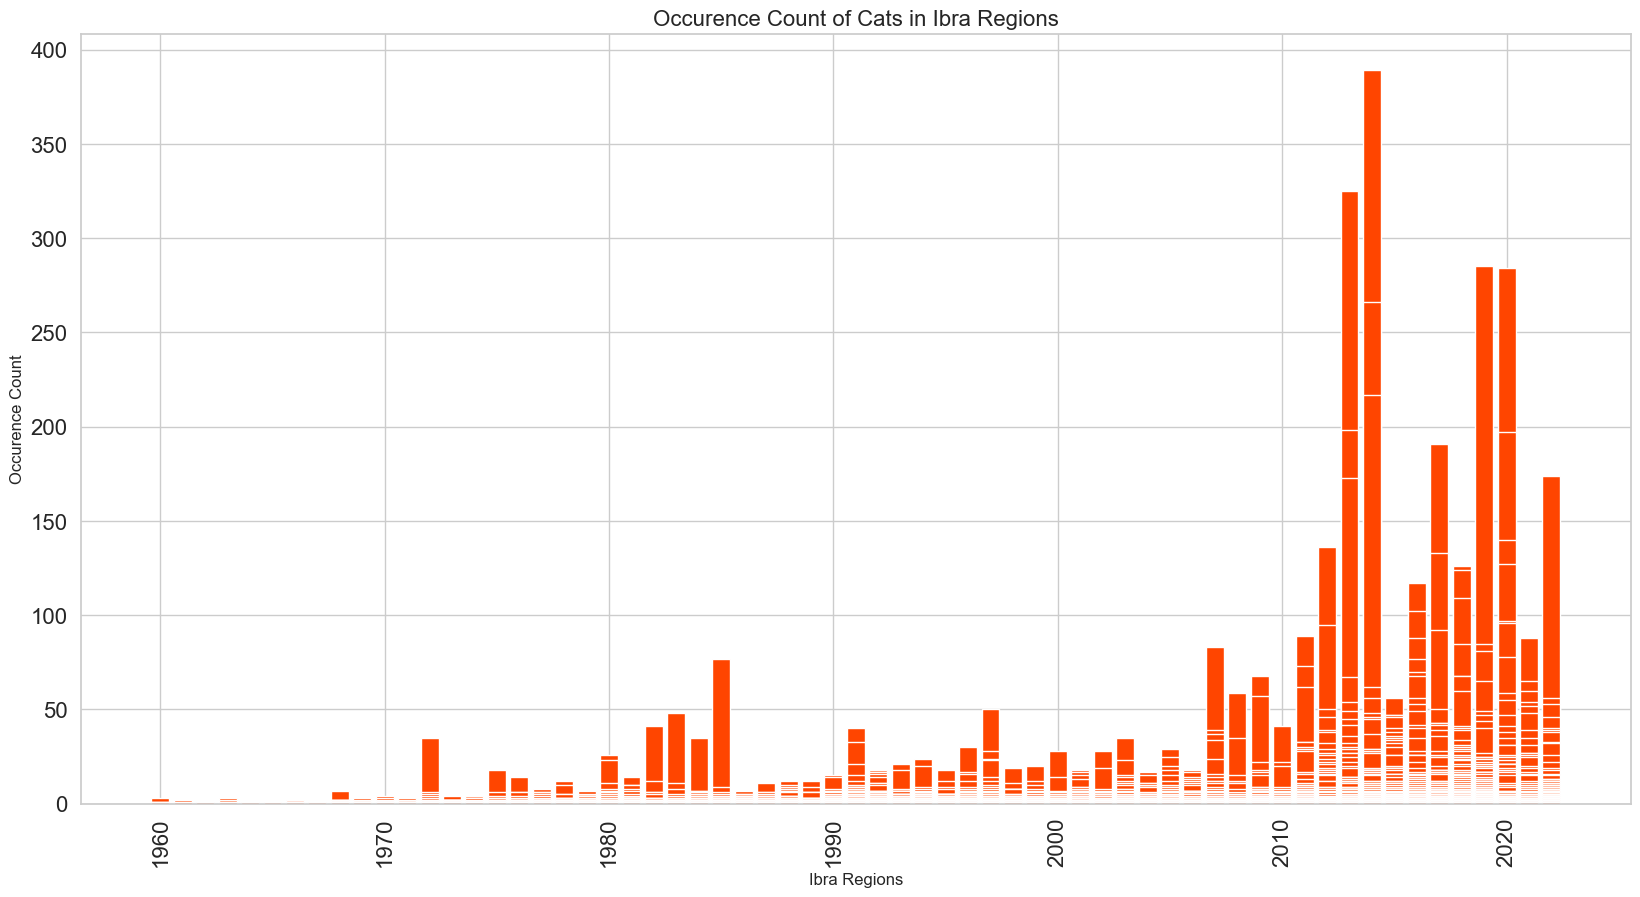

In [ ]:
rt_df_sorted = rt_df.sort_values(by='occurrenceCount', ascending=False)
plt.figure(figsize=(20, 10))
plt.bar(rt_df_sorted['year'], rt_df_sorted['occurrenceCount'], color='orangered')
plt.xlabel('States')
plt.ylabel('Occurence Count')
plt.title('Occurence Count of Cats in Ibra Regions', fontsize=16)
plt.xticks(rotation = 90, fontsize=16)
plt.yticks(fontsize=16)
plt.show()

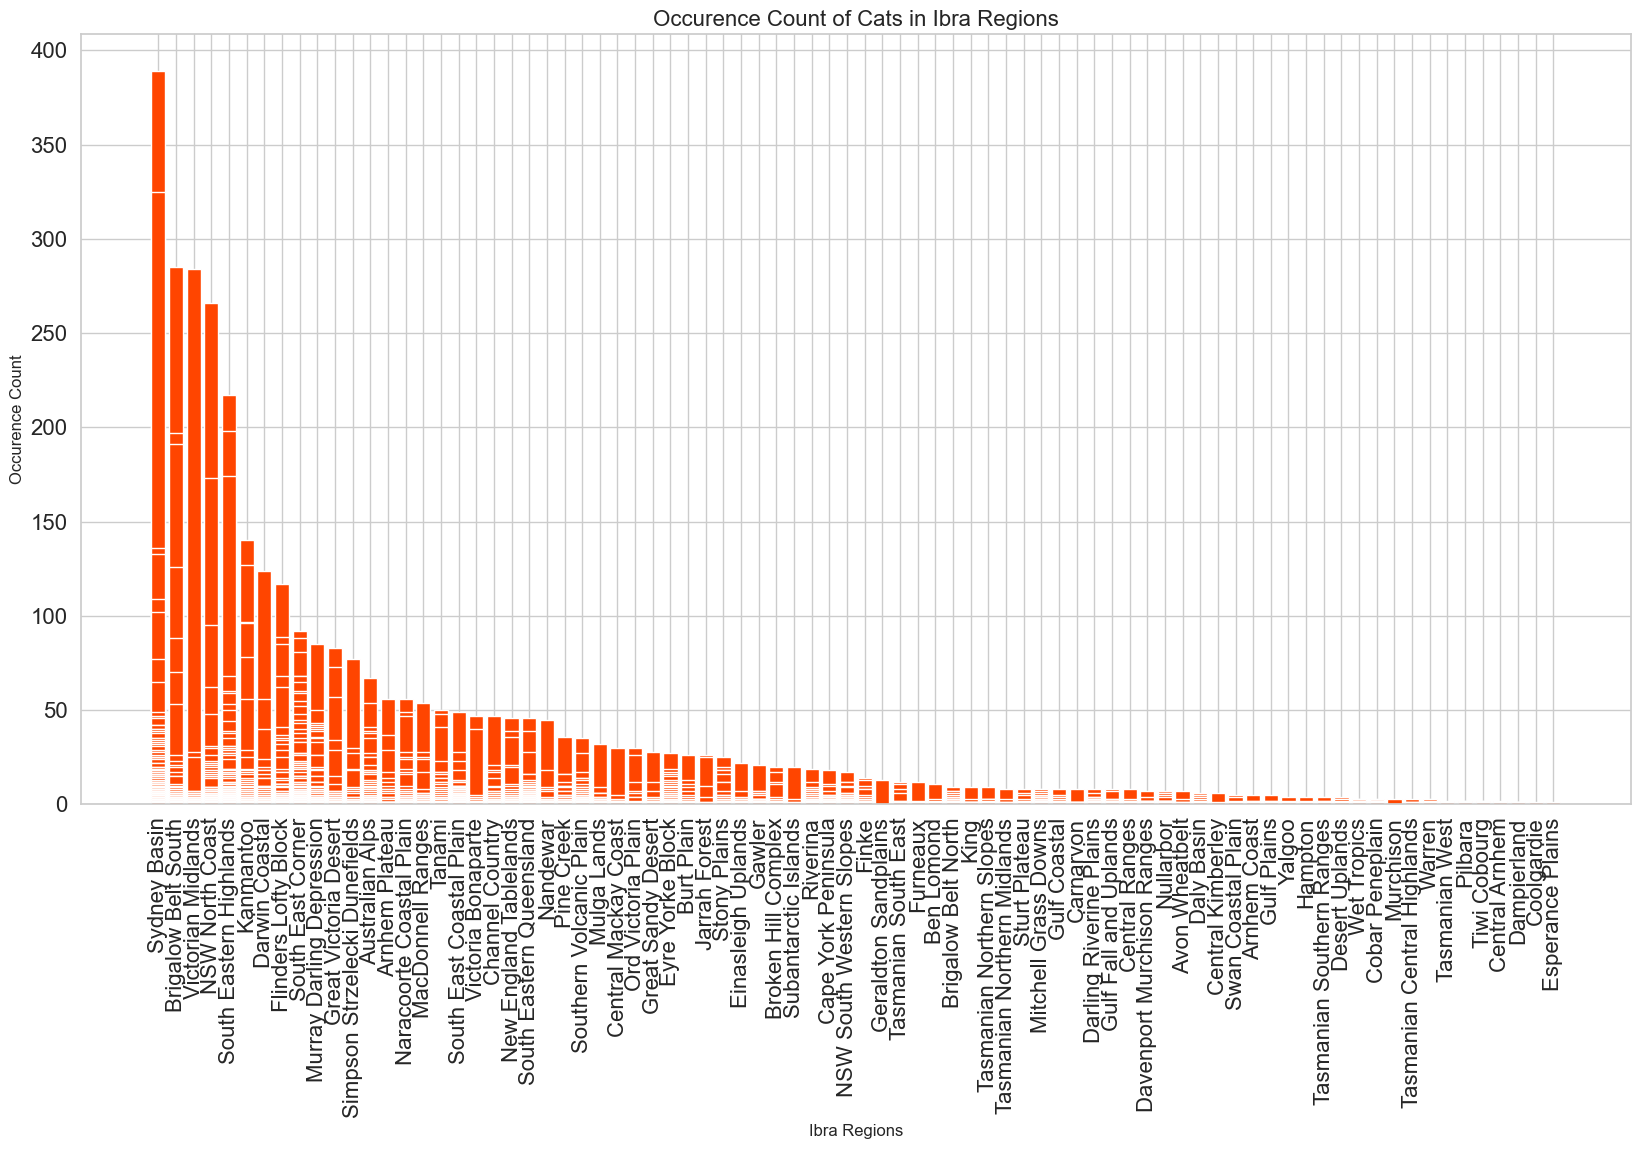

In [ ]:
rt_df_sorted = rt_df.sort_values(by='occurrenceCount', ascending=False)
plt.figure(figsize=(20, 10))
plt.bar(rt_df_sorted['ibraRegion'], rt_df_sorted['occurrenceCount'], color='orangered')
plt.xlabel('Ibra Regions')
plt.ylabel('Occurence Count')
plt.title('Occurence Count of Cats in Ibra Regions', fontsize=16)
plt.xticks(rotation = 90, fontsize=16)
plt.yticks(fontsize=16)
plt.show()

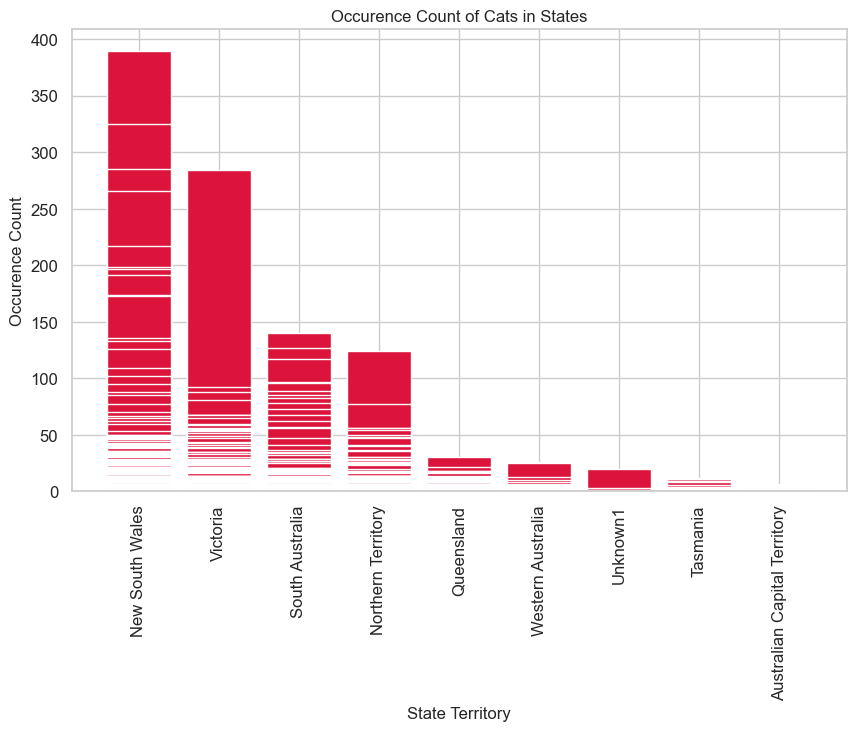

In [47]:
plt.figure(figsize=(10, 6))
plt.bar(rt_df_sorted['stateTerritory'], rt_df_sorted['occurrenceCount'], color='crimson')
plt.xlabel('State Territory')
plt.ylabel('Occurence Count')
plt.title('Occurence Count of Cats in States')
plt.xticks(rotation = 90, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

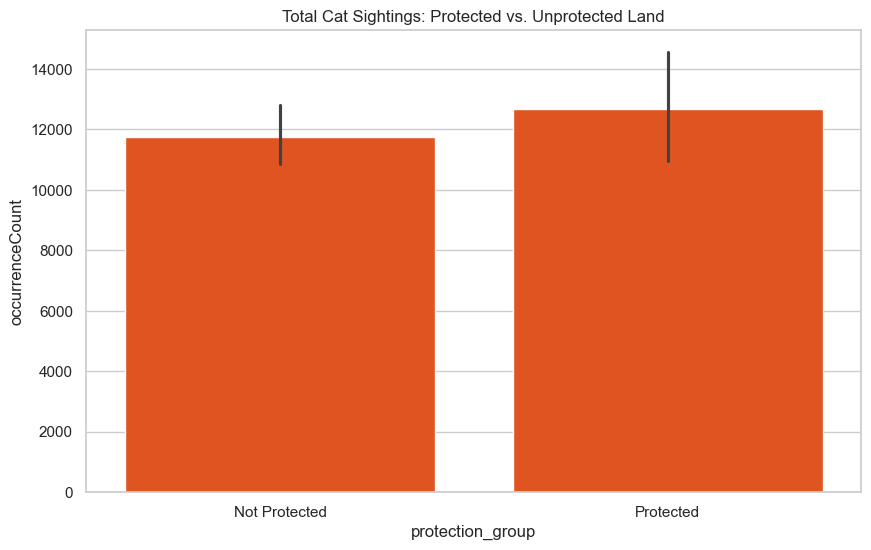

In [48]:
import seaborn as sns

# Combining PA and IPA
rt_df['protection_group'] = rt_df['is_protected'].map({0: 'Not Protected', 1: 'Protected', 2: 'Protected'})

# Comparing the volume of sightings (occurrenceCount) across protection types
plt.figure(figsize=(10, 6))
sns.barplot(data=rt_df, x='protection_group', y='occurrenceCount', estimator=sum, color='orangered')
plt.title('Total Cat Sightings: Protected vs. Unprotected Land')
plt.show()

In [49]:
rt_df['ibraRegion'].unique()

array(['South East Corner', 'South Eastern Highlands',
       'South Eastern Queensland', 'Daly Basin',
       'Murray Darling Depression', 'Riverina', 'Mulga Lands', 'Pilbara',
       'Sydney Basin', 'Eyre Yorke Block', 'Central Ranges',
       'Flinders Lofty Block', 'Brigalow Belt South',
       'Southern Volcanic Plain', 'MacDonnell Ranges', 'Nullarbor',
       'Victorian Midlands', 'Burt Plain', 'Davenport Murchison Ranges',
       'Finke', 'Simpson Strzelecki Dunefields',
       'NSW South Western Slopes', 'Kanmantoo',
       'Naracoorte Coastal Plain', 'Mitchell Grass Downs',
       'Darling Riverine Plains', 'Gawler', 'South East Coastal Plain',
       'NSW North Coast', 'Great Sandy Desert', 'Sturt Plateau', 'Tanami',
       'Central Mackay Coast', 'Pine Creek', 'Victoria Bonaparte',
       'Cape York Peninsula', 'Darwin Coastal', 'Australian Alps',
       'Brigalow Belt North', 'Arnhem Plateau',
       'Tasmanian Northern Slopes', 'Channel Country', 'Nandewar',
       'Furnea

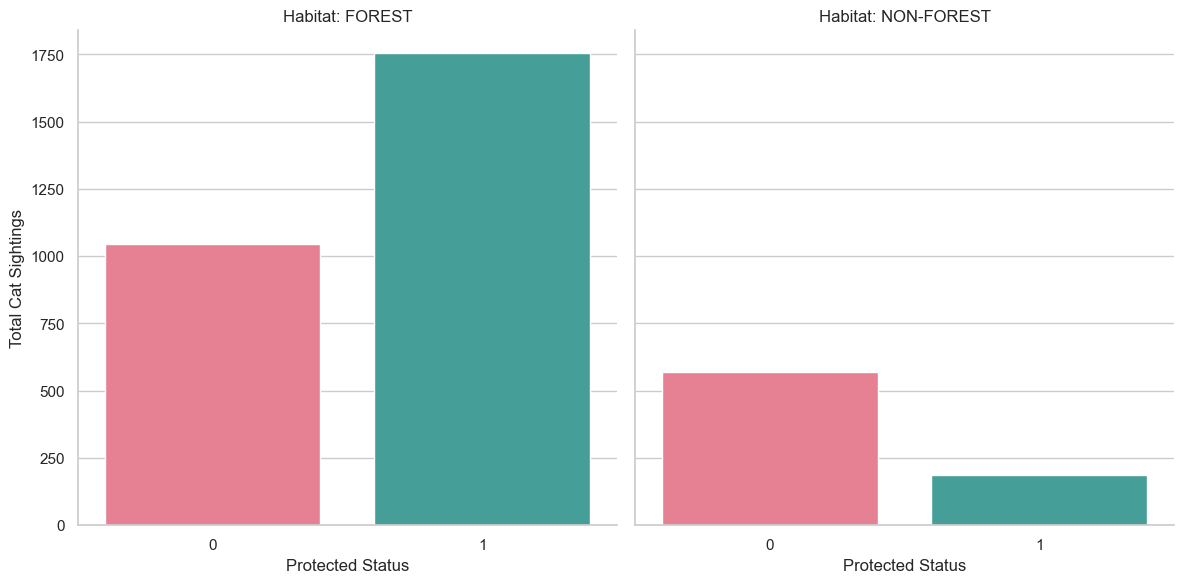

In [ ]:
# Places with high sheep density 
# source: https://www.mla.com.au/news-and-events/industry-news/find-out-the-top-sheep-and-cattle-regions-in-your-state/
sheep_regions = ['Riverina', 'NSW South West Slopes', 'South Eastern Highlands', 'Jarrah Forest', 'Broken Hill Complex', 'Naracoorte Coastal Plain', 'Avon Wheatbelt']
sheep_df = rt_df[rt_df['ibraRegion'].isin(sheep_regions)]

rt_df['forest2018Status'] = rt_df['forest2018Status'].str.upper()

sns.set_theme(style="whitegrid")
# Create FacetGrid to compare Protection vs Forest Status
facet = sns.FacetGrid(sheep_df, col="forest2018Status", height=6, aspect=1)
facet.map_dataframe(sns.barplot, x="is_protected", y="occurrenceCount", estimator='sum', hue='is_protected', palette="husl", errorbar=None)
facet.set_axis_labels("Protected Status", "Total Cat Sightings")
facet.set_titles("Habitat: {col_name}")
plt.show()

In [51]:
sheep_df['ibraRegion'].unique()

array(['South Eastern Highlands', 'Riverina', 'Naracoorte Coastal Plain',
       'Avon Wheatbelt', 'Broken Hill Complex', 'Jarrah Forest'],
      dtype=object)

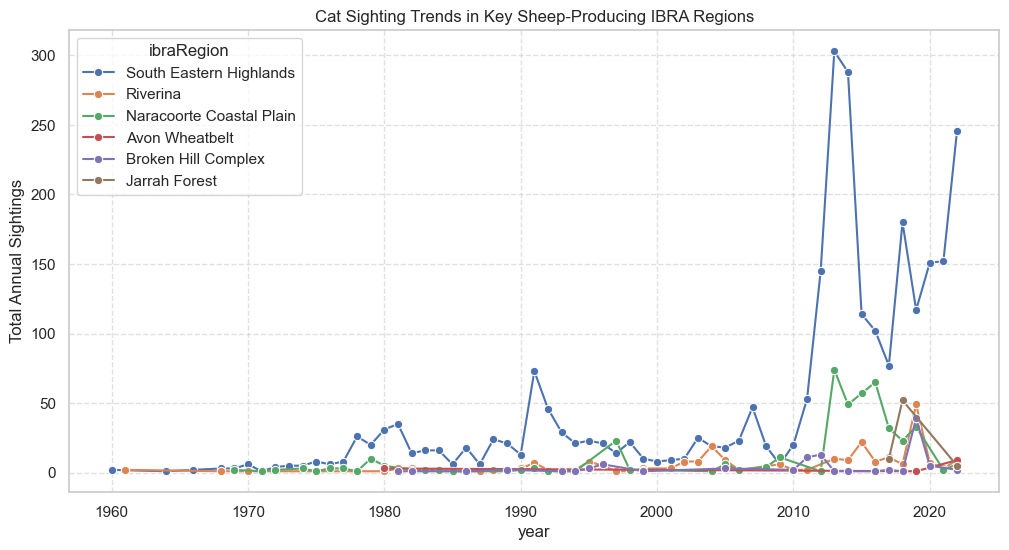

In [52]:
plt.figure(figsize=(12, 6))
# Sheep regions only and sum occurrences by year
trend_df = sheep_df.groupby(['year', 'ibraRegion'])['occurrenceCount'].sum().reset_index()

sns.lineplot(data=trend_df, x='year', y='occurrenceCount', hue='ibraRegion', marker='o')
plt.title('Cat Sighting Trends in Key Sheep-Producing IBRA Regions')
plt.ylabel('Total Annual Sightings')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

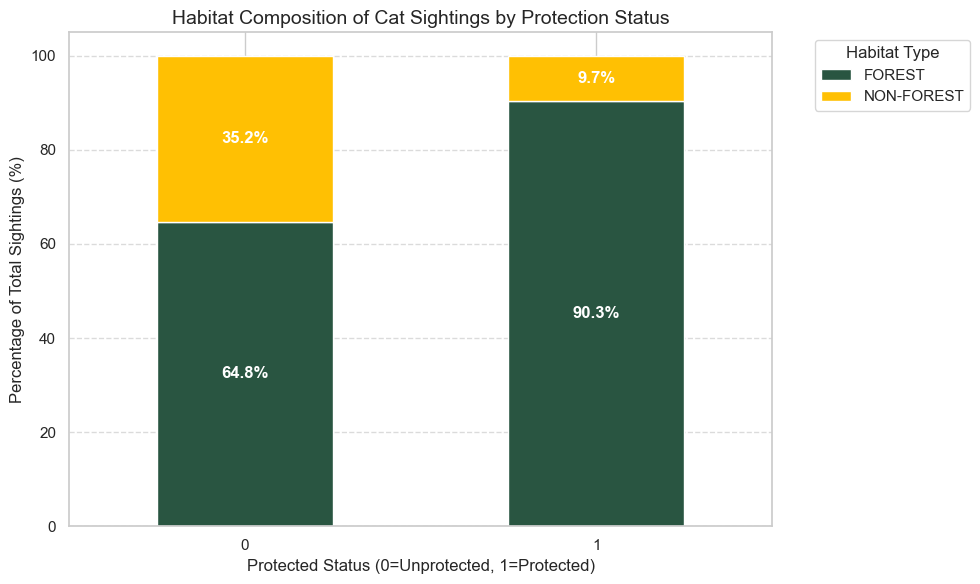

In [53]:
comp = sheep_df.groupby(['is_protected', 'forest2018Status'])['occurrenceCount'].sum().unstack()
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100

ax = comp_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#295541", "#ffc003"])

# Formatting
plt.title('Habitat Composition of Cat Sightings by Protection Status', fontsize=14)
plt.ylabel('Percentage of Total Sightings (%)')
plt.xlabel('Protected Status (0=Unprotected, 1=Protected)')
plt.xticks(rotation=0)
plt.legend(title='Habitat Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add % labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0: # Only label if there is value
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [56]:
rt_df['stateTerritory'].unique()

array(['New South Wales', 'Australian Capital Territory',
       'Northern Territory', 'Victoria', 'Queensland',
       'Western Australia', 'South Australia', 'Tasmania', 'Unknown1'],
      dtype=object)

In [57]:
sheep_states = ['New South Wales', 'Western Australia', 'South Australia', 'Victoria']
sheep_df = rt_df[rt_df['stateTerritory'].isin(sheep_states)]

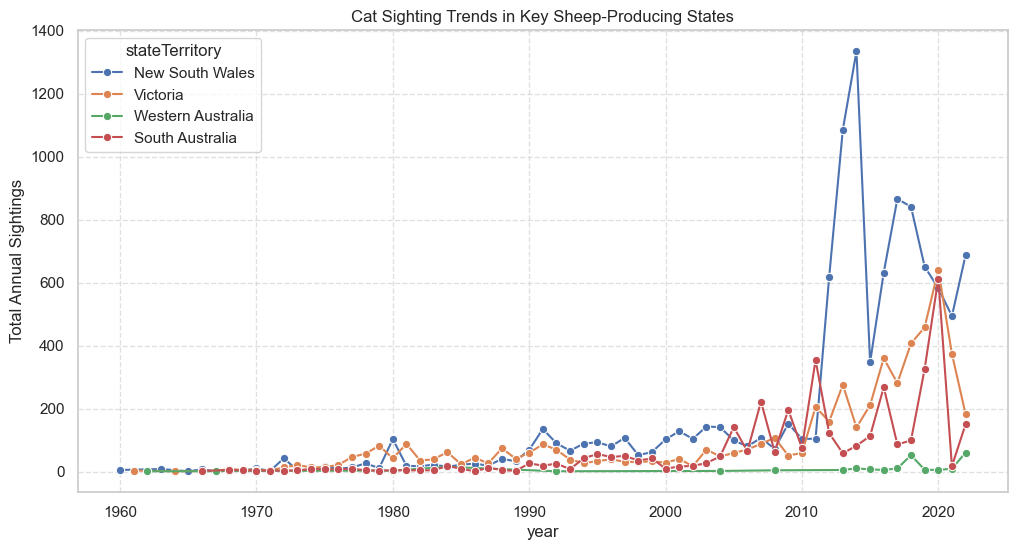

In [58]:
plt.figure(figsize=(12, 6))
# Sheep regions only and sum occurrences by year
trend_df = sheep_df.groupby(['year', 'stateTerritory'])['occurrenceCount'].sum().reset_index()

sns.lineplot(data=trend_df, x='year', y='occurrenceCount', hue='stateTerritory', marker='o')
plt.title('Cat Sighting Trends in Key Sheep-Producing States')
plt.ylabel('Total Annual Sightings')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()